In [29]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from nltk.sentiment import SentimentIntensityAnalyzer

import matplotlib.pyplot as plt
import seaborn as sns

path = "Amazon_Unlocked_Mobile.csv"

# Preprocesamiento

In [3]:
df1 = pd.read_csv(path)
df1 = df1.dropna(subset=["Reviews"]) 
Rating = df1["Rating"]
Reviews = df1["Reviews"]

def positivo_negativo(rating):
    return [1 if r >= 4 else 0 for r in rating]
df1["Nuevo Rating"] = positivo_negativo(Rating)

def reviewN(reviews):
    # TfidfVectorizer convierte texto en una matriz de características numéricas
    # donde cada palabra tiene un peso (TF-IDF) que refleja su importancia en el documento
    vectorizer = TfidfVectorizer()
    
    # Transformación del texto a representación numérica
    # fit_transform hace dos cosas:
    # Aprende el vocabulario
    # Transforma las reviews en una matriz sparse
    # El resultado es una matriz donde:
    # Cada fila representa una review
    # Cada columna representa una palabra del vocabulario
    # Cada celda contiene el valor TF-IDF de esa palabra en esa review
    tfidf_matrix = vectorizer.fit_transform(reviews)
    
    # Cálculo del valor numérico promedio por review
    # mean(axis=1) calcula el promedio de los valores TF-IDF para cada review (por fila)
    # Esto da un solo valor numérico que representa la "importancia promedio" de las palabras en cada review
    # getA1() convierte el resultado de formato matriz numpy a un array unidimensional
    numeric_values = tfidf_matrix.mean(axis=1).getA1()
    return numeric_values
df1["Review Numerico"] = reviewN(Reviews)
df1.reset_index(drop=True, inplace=True)
df1

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Nuevo Rating,Review Numerico
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0,1,0.000102
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0,1,0.000074
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0,1,0.000020
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0,1,0.000046
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0,1,0.000078
...,...,...,...,...,...,...,...,...
413765,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0,1,0.000029
413766,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0,0,0.000015
413767,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0,1,0.000037
413768,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,I returned it because it did not meet my needs...,0.0,0,0.000053


In [ ]:
#Se descarga una libreria extra (en caso de no contar con ella)
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\crdie\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
#Se trabaja con sentiment Analyzer para diferenciar reviews positivas, negativas y neutras con un score
sia = SentimentIntensityAnalyzer()
results = {}

for row in df1.iterrows():
    text = row[1]["Reviews"]
    score = sia.polarity_scores(text)
    results[row[0]] = score

sentiment_score = pd.DataFrame(results).T

sentiment_score

,neg,neu,pos,compound
0,0.015,0.796,0.189,0.8783
1,0.072,0.597,0.331,0.9231
2,0.000,0.238,0.762,0.4927
3,0.000,0.500,0.500,0.9185
4,0.038,0.897,0.065,0.2942
...,...,...,...,...
413765,0.000,0.268,0.732,0.8481
413766,0.000,0.000,1.000,0.2960
413767,0.285,0.715,0.000,-0.3382
413768,0.000,0.806,0.194,0.5927


In [ ]:
#Se agrega un label al index

sentiment_score.index.name = 'id'
sentiment_score

,neg,neu,pos,compound
id,,,,
0,0.015,0.796,0.189,0.8783
1,0.072,0.597,0.331,0.9231
2,0.000,0.238,0.762,0.4927
3,0.000,0.500,0.500,0.9185
4,0.038,0.897,0.065,0.2942
...,...,...,...,...
413765,0.000,0.268,0.732,0.8481
413766,0.000,0.000,1.000,0.2960
413767,0.285,0.715,0.000,-0.3382


In [ ]:
#Se agrega un label al index
df1.index.name = "id"

df1

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Nuevo Rating,Review Numerico
id,,,,,,,,
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0,1,0.000102
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0,1,0.000074
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0,1,0.000020
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0,1,0.000046
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0,1,0.000078
...,...,...,...,...,...,...,...,...
413765,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0,1,0.000029
413766,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0,0,0.000015
413767,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0,1,0.000037


In [ ]:
#uniendo los dataFrame
df_combined = df1.join(sentiment_score)

df_combined

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Nuevo Rating,Review Numerico,neg,neu,pos,compound
id,,,,,,,,,,,,
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0,1,0.000102,0.015,0.796,0.189,0.8783
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0,1,0.000074,0.072,0.597,0.331,0.9231
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0,1,0.000020,0.000,0.238,0.762,0.4927
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0,1,0.000046,0.000,0.500,0.500,0.9185
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0,1,0.000078,0.038,0.897,0.065,0.2942
...,...,...,...,...,...,...,...,...,...,...,...,...
413765,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0,1,0.000029,0.000,0.268,0.732,0.8481
413766,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0,0,0.000015,0.000,0.000,1.000,0.2960
413767,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0,1,0.000037,0.285,0.715,0.000,-0.3382


In [ ]:
#Se cambia a numerica la variable de Brand Name

brands = df_combined['Brand Name'].unique()

for i, brand in enumerate(brands):
    df_combined.loc[df_combined["Brand Name"] == brand, "Brand"] = i+1

df_combined

,Product Name,Brand Name,Price,Rating,Reviews,Review Votes,Nuevo Rating,Review Numerico,neg,neu,pos,compound,Brand
id,,,,,,,,,,,,,
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0,1,0.000102,0.015,0.796,0.189,0.8783,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0,1,0.000074,0.072,0.597,0.331,0.9231,1.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0,1,0.000020,0.000,0.238,0.762,0.4927,1.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0,1,0.000046,0.000,0.500,0.500,0.9185,1.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0,1,0.000078,0.038,0.897,0.065,0.2942,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413765,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,another great deal great price,0.0,1,0.000029,0.000,0.268,0.732,0.8481,1.0
413766,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,3,Ok,0.0,0,0.000015,0.000,0.000,1.000,0.2960,1.0
413767,Samsung Convoy U640 Phone for Verizon Wireless...,Samsung,79.95,5,Passes every drop test onto porcelain tile!,0.0,1,0.000037,0.285,0.715,0.000,-0.3382,1.0


In [ ]:
#Se filtran las columnas a usar
cols = ['Price', 'Review Votes', 'Review Numerico', 'pos', 'neu', 'neg', 'compound', 'Brand', 'Nuevo Rating']
data = df_combined[cols]

data

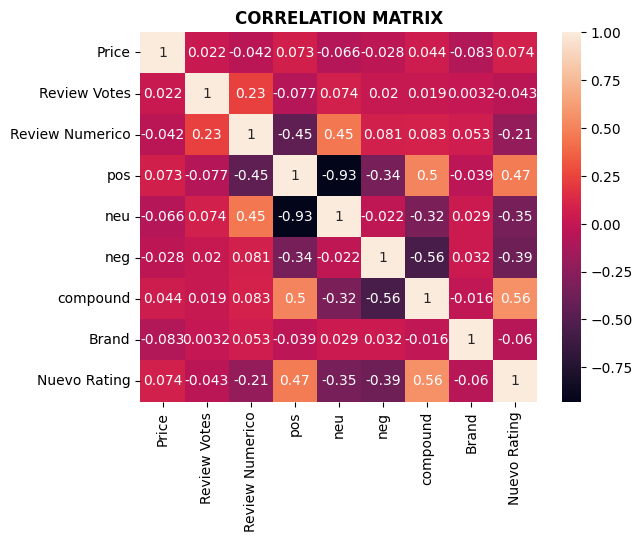

In [30]:
#Matiz de correlacion

plt.figure()
sns.heatmap(data.corr(), annot=True)
plt.title('CORRELATION MATRIX', fontweight='bold')
plt.show()
print("")

# Implementación de modelos 

Se implementarán modelos de clasificación de Decision Tree, Random Forest y Support Vector Machine para predecir si un producto tiene una review buena o mala. Por lo que se intentará predecir la columna 'Nuevo Rating'

In [ ]:
X = df_combined[['Price', 'Review Numerico', 'Review Votes', 'neg', 'neu', 'pos', 'compound', 'Brand']]
y = df_combined['Nuevo Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("N° of row in X_train: ", X_train.shape[0])
print("N° of row in X_test: ", X_test.shape[0])
print("N° of row in y_train: ", y_train.shape[0])
print("N° of row in y_test: ", y_test.shape[0])

N° of row in X_train:  331016
N° of row in X_test:  82754
N° of row in y_train:  331016
N° of row in y_test:  82754


### Decision Tree - Manual


In [39]:
#Realizando el modelo Decision Tree Classifier de manera manual
dt_classifier = DecisionTreeClassifier(max_depth=12, min_samples_leaf=10, random_state=42)
dt_classifier.fit(X_train, y_train)

# Predicciones
y_pred_dt_train = dt_classifier.predict(X_train)
y_pred_dt_test = dt_classifier.predict(X_test)

In [46]:
# Evaluación del entrenamiento
print("Resultados de Decision Tree en Entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train, y_pred_dt_train):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred_dt_train))

Resultados de Decision Tree en Entrenamiento:
Accuracy: 0.8622
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.76      0.78    103058
           1       0.89      0.91      0.90    227958

    accuracy                           0.86    331016
   macro avg       0.84      0.84      0.84    331016
weighted avg       0.86      0.86      0.86    331016



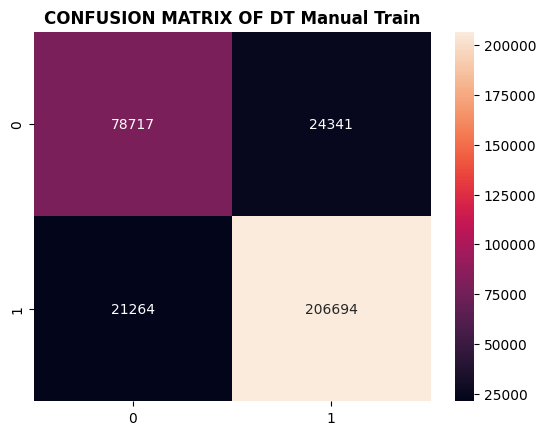

In [50]:
plt.figure()
sns.heatmap(confusion_matrix(y_train, y_pred_dt_train), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF DT Manual Train', fontweight='bold')
plt.show()

In [51]:
# Evaluación del test
print("Resultados de Decision Tree en Test:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_test):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt_test))

Resultados de Decision Tree en Test:
Accuracy: 0.8493
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.74      0.75     25764
           1       0.88      0.90      0.89     56990

    accuracy                           0.85     82754
   macro avg       0.83      0.82      0.82     82754
weighted avg       0.85      0.85      0.85     82754



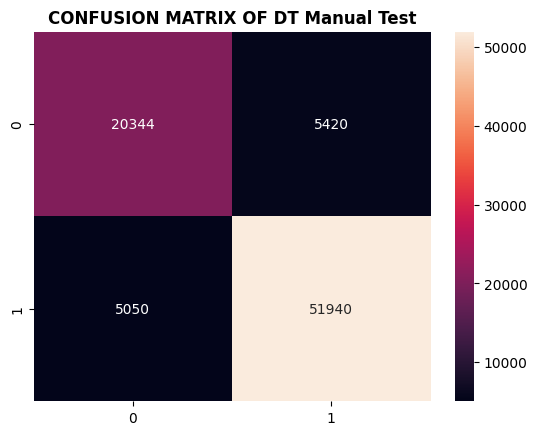

In [58]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_dt_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF DT Manual Test', fontweight='bold')
plt.show()

### Decision Tree - GridSearch

In [55]:
dt_classifier = DecisionTreeClassifier()
param_dt_classif = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [10, 12, 20],
    'min_samples_leaf': [5, 10, 15] 
}

grid_search_dt = GridSearchCV(estimator=dt_classifier, param_grid=param_dt_classif, cv=5, verbose=1)
grid_search_dt.fit(X_train, y_train)
best_class_dt = grid_search_dt.best_estimator_

best_class_dt

Fitting 5 folds for each of 27 candidates, totalling 135 fits


DecisionTreeClassifier(max_depth=20, min_samples_leaf=5)

In [56]:
# Predicciones
y_pred_dt_train = best_class_dt.predict(X_train)
y_pred_dt_test = best_class_dt.predict(X_test)

In [ ]:
# Evaluación del entrenamiento
print("Resultados de Decision Tree en Entrenamiento:")
print(f"Accuracy: {accuracy_score(y_train, y_pred_dt_train):.4f}")
print("Classification Report:")
print(classification_report(y_train, y_pred_dt_train))

Resultados de Decision Tree en Entrenamiento:
Accuracy: 0.9213
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87    103058
           1       0.94      0.94      0.94    227958

    accuracy                           0.92    331016
   macro avg       0.91      0.91      0.91    331016
weighted avg       0.92      0.92      0.92    331016



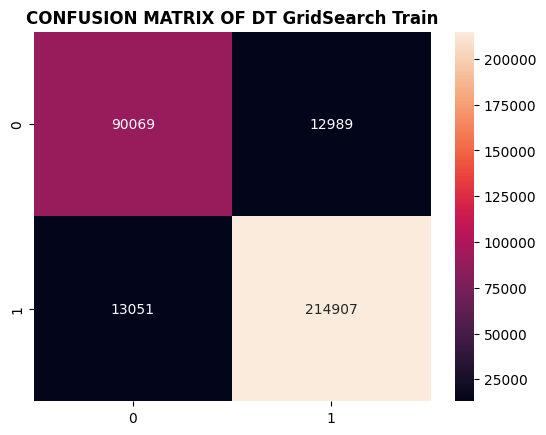

In [59]:
plt.figure()
sns.heatmap(confusion_matrix(y_train, y_pred_dt_train), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF DT GridSearch Train', fontweight='bold')
plt.show()

In [60]:
# Evaluación del test
print("Resultados de Decision Tree en Test:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_test):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt_test))

Resultados de Decision Tree en Test:
Accuracy: 0.8735
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.79      0.80     25764
           1       0.91      0.91      0.91     56990

    accuracy                           0.87     82754
   macro avg       0.85      0.85      0.85     82754
weighted avg       0.87      0.87      0.87     82754



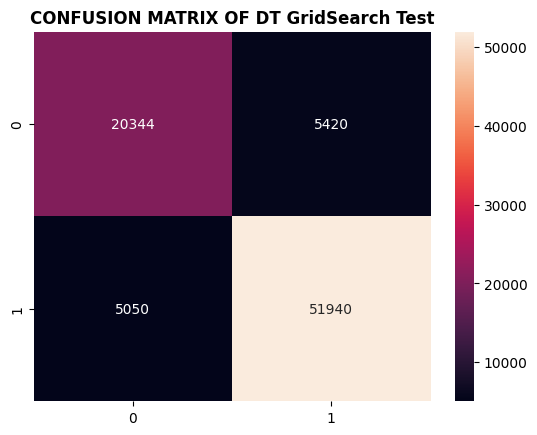

In [61]:
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_dt_test), annot=True, fmt='g')
plt.title('CONFUSION MATRIX OF DT GridSearch Test', fontweight='bold')
plt.show()